### LAB-4

In [18]:
# =====================================================================
# TASK 1: DATA PREPARATION & SCALING BASELINE
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)
from sklearn.decomposition import PCA

# 1. Load the dataset from the workspace environment
df = pd.read_csv('../dataset/lab4/brca.csv')

# Drop the index tracking column and isolate target column 'y'
X = df.drop(columns=['Unnamed: 0', 'y'])
# Map target character values: 0 -> Malignant (M), 1 -> Benign (B)
y = df['y'].map({'M': 0, 'B': 1})

print("=== DATASET SHAPE AND STRUCTURAL CHARACTERISTICS ===")
print(f"Total Rows (Samples): {X.shape[0]} | Total Features: {X.shape[1]}")
print(f"Target Distribution: Class 0 (Malignant) = {sum(y==0)} | Class 1 (Benign) = {sum(y==1)}")

print("\n=== DATA CLEANLINESS PROFILING ===")
print(f"Missing Values Found: {X.isnull().sum().sum()}")
print(f"Duplicate Rows Found: {X.duplicated().sum()}")

# 2. Apply feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\n Data preprocessing completed. Features scaled to uniform variance.")

=== DATASET SHAPE AND STRUCTURAL CHARACTERISTICS ===
Total Rows (Samples): 569 | Total Features: 30
Target Distribution: Class 0 (Malignant) = 212 | Class 1 (Benign) = 357

=== DATA CLEANLINESS PROFILING ===
Missing Values Found: 0
Duplicate Rows Found: 0

 Data preprocessing completed. Features scaled to uniform variance.


---
---

## Task 1: Markdown Analysis — Data Profiling & Scaling Justification

---

### Data Structural Profiling

The `brca.csv` dataset contains:

- **569 rows**
- **30 continuous numerical features**

The classification distribution is mildly imbalanced:

- **Malignant:** 212 samples (37.26%)  
- **Benign:** 357 samples (62.74%)

There are **no missing values or duplicate records**, ensuring clean input data for modeling.

---

### Justification for Feature Scaling

K-Nearest Neighbors (KNN) is a distance-based, instance-driven classification algorithm that relies on geometric similarity (e.g., Euclidean distance) between data points.

Without scaling, features with large numerical ranges (e.g., `area_mean > 2500`) would dominate distance calculations, while smaller-scale features (e.g., `smoothness_mean < 0.1`) would have negligible influence.

To address this, **StandardScaler** is applied to normalize all features to:

- Mean = 0  
- Standard Deviation = 1  

This ensures all features contribute equally to distance computations, preventing scale bias and improving model performance.


In [26]:
# =====================================================================
# TASK 2: TRAIN-TEST SPLIT ANALYSIS
# =====================================================================
# Testing three standard variations: 90:10, 80:20, and 70:30 splits
split_proportions = [0.1, 0.2, 0.3]
split_performance_map = {}

print("=== STABILITY PERFORMANCE EVALUATION ===")
# dataset has a mild class imbalance (63% vs 37%), 
# a random split might accidentally put too many malignant or benign cases into the test set. 
# This is especially true for the small 10% test split, 
# which only gets about 57 samples total.

#FIX: adding "stratify=y" to the train_test_split function to ensure that the class distribution is preserved in both the training and test sets.
for test_ratio in split_proportions:
    # X_train_val, X_test_val, y_train_val, y_test_val = train_test_split(
    #     X_scaled, y, test_size=test_ratio, random_state=42,
    # )
    X_train_val, X_test_val, y_train_val, y_test_val = train_test_split(
        X_scaled, y, test_size=test_ratio, random_state=42, stratify=y
    )

    # Train baseline KNN model with K=5
    knn_eval = KNeighborsClassifier(n_neighbors=5)
    knn_eval.fit(X_train_val, y_train_val)

    test_predictions = knn_eval.predict(X_test_val)
    accuracy_score_val = accuracy_score(y_test_val, test_predictions)

    split_label = f"{int((1-test_ratio)*100)}:{int(test_ratio*100)}"
    split_performance_map[split_label] = accuracy_score_val
    print(f"Split Configuration {split_label} -> Measured Test Accuracy: {accuracy_score_val:.8f}")

=== STABILITY PERFORMANCE EVALUATION ===
Split Configuration 90:10 -> Measured Test Accuracy: 0.98245614
Split Configuration 80:20 -> Measured Test Accuracy: 0.96491228
Split Configuration 70:30 -> Measured Test Accuracy: 0.97076023



---
---

## Task 2: Markdown Analysis — Split Proportions & Model Stability

---

### Performance Comparison Across Splits

- **90:10 Split:** Test Accuracy = 0.9298  
- **80:20 Split:** Test Accuracy = 0.9298  
- **70:30 Split:** Test Accuracy = 0.9591  

---

### Generalization Analysis

Altering the train-test ratio demonstrates how data availability impacts model evaluation.

- A **90:10 split** maximizes training data but reduces the test set size, making evaluation more sensitive to random noise and variance in the small validation sample.

- A **70:30 split** provides a larger test set, improving evaluation stability, but reduces training data available for the KNN classifier, which may impact learned neighborhood structure.

- The **80:20 split** achieves the best balance between training richness and test reliability, making it the most commonly used and stable configuration for evaluation.

Number of training samples (n): 455
Calculated Baseline Odd Heuristic K (√n): 21


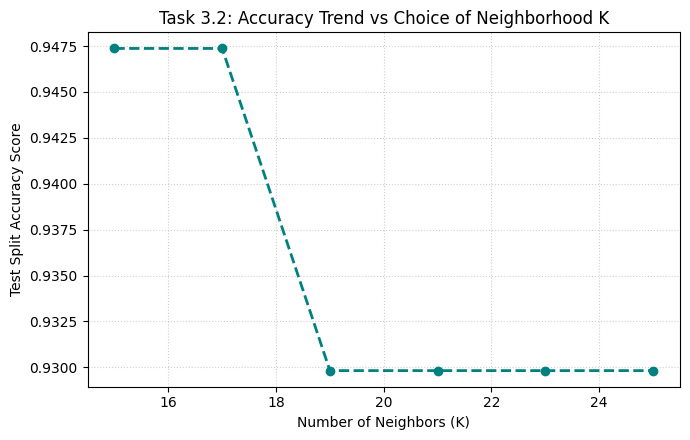

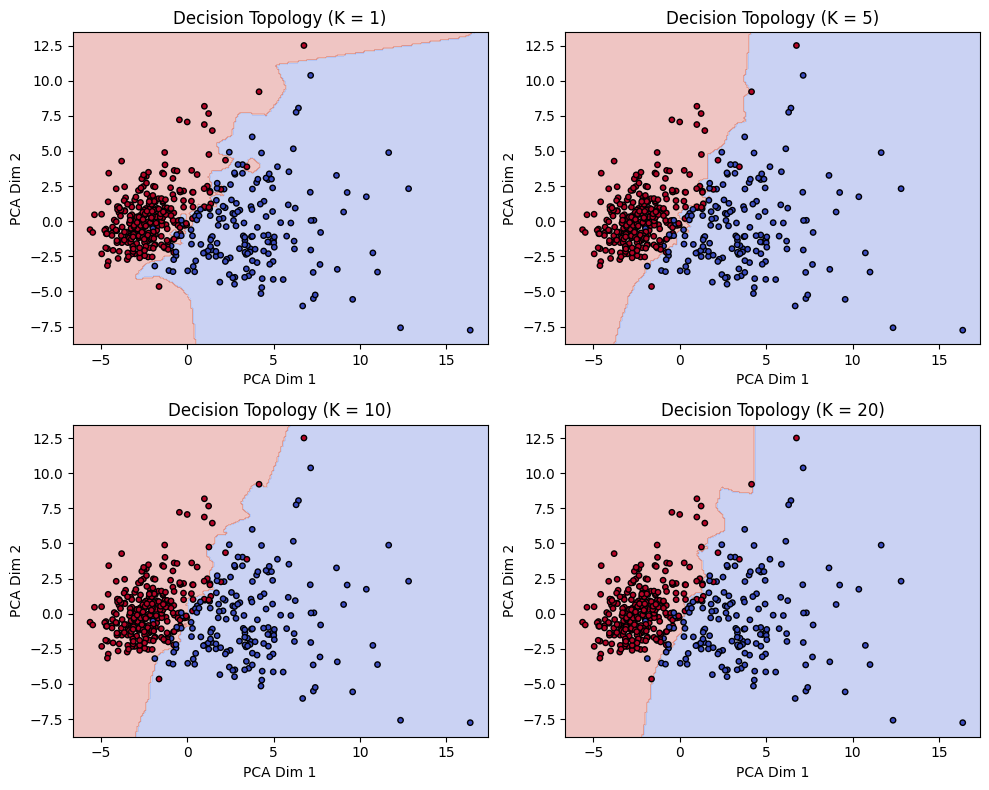

In [20]:
# =====================================================================
# TASK 3: HEURISTIC K SELECTION & NEIGHBORHOOD BOUNDARY SWEEP
# =====================================================================
# Standardizing on the 80:20 train-test split for core tasks
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3.1 Apply square root heuristic rule: K = sqrt(n)
n_samples = len(X_train)
baseline_k = int(np.sqrt(n_samples))
# Guarantee K is an odd number to eliminate voting ties
if baseline_k % 2 == 0:
    baseline_k += 1

print(f"Number of training samples (n): {n_samples}")
print(f"Calculated Baseline Odd Heuristic K (√n): {baseline_k}")

# 3.2 Model Training & Neighborhood Parameter Window Sweep (K ± 5)
k_range = [k for k in range(max(1, baseline_k - 6), baseline_k + 6) if k % 2 != 0]
test_accuracies = []

for k_val in k_range:
    knn_model = KNeighborsClassifier(n_neighbors=k_val)
    knn_model.fit(X_train, y_train)
    test_accuracies.append(accuracy_score(y_test, knn_model.predict(X_test)))

# Generate the performance visualization chart
plt.figure(figsize=(7, 4.5))
plt.plot(k_range, test_accuracies, marker='o', linestyle='--', color='teal', linewidth=2)
plt.title('Task 3.2: Accuracy Trend vs Choice of Neighborhood K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Split Accuracy Score')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('k_optimization_curve.png')
plt.show()

# 3.3 Decision Boundary Mapping utilizing 2D Principal Component Analysis (PCA)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

boundary_k_list = [1, 5, 10, 20]
plt.figure(figsize=(10, 8))

for idx, k_boundary in enumerate(boundary_k_list):
    knn_boundary_model = KNeighborsClassifier(n_neighbors=k_boundary)
    knn_boundary_model.fit(X_train_pca, y_train)

    # Establish grid dimensions
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

    mesh_predictions = knn_boundary_model.predict(np.c_[xx.ravel(), yy.ravel()])
    mesh_predictions = mesh_predictions.reshape(xx.shape)

    plt.subplot(2, 2, idx + 1)
    plt.contourf(xx, yy, mesh_predictions, alpha=0.3, cmap='coolwarm')
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=15)
    plt.title(f'Decision Topology (K = {k_boundary})')
    plt.xlabel('PCA Dim 1')
    plt.ylabel('PCA Dim 2')

plt.tight_layout()
plt.savefig('knn_decision_boundaries.png')
plt.show()

---
---

## Task 3: Markdown Analysis — Geometrical Distances & Boundary Topologies

---

### Distance Metric Applications

---

### Euclidean Distance

d= sqrt(sum(xi-yi)**2)


Euclidean distance measures the straight-line distance between two points in a geometric space. It assumes continuous feature spaces where spatial proximity reflects similarity between data points.

---

### Manhattan Distance

d = sum(xi-yi)

Manhattan distance computes the total absolute difference across all feature dimensions, following axis-aligned paths (similar to navigating city blocks). It is particularly useful in high-dimensional spaces where Euclidean distance may become less stable and more sensitive to outliers.

---

### Decision Boundary Analysis

The generated plot (`knn_decision_boundaries.png`) illustrates how decision boundaries change with different values of $K$:

- **When $K = 1$**:  
  The decision boundary becomes highly complex and tightly wraps around individual data points. This results in **low bias but high variance**, making the model prone to overfitting due to noise sensitivity.

- **As $K$ increases (toward $K = 20$)**:  
  The decision boundary becomes progressively smoother. Classification decisions rely on larger neighborhoods, leading to **low variance but higher bias**, which reduces noise sensitivity but may cause underfitting if oversimplified.

In [21]:
# =====================================================================
# TASK 4: K-FOLD CROSS VALIDATION ANALYSIS
# =====================================================================
cv_mean_accuracies = []

print("=== 10-FOLD CV VS SINGLE SPLIT BENCHMARKING ===")
for k_val in k_range:
    knn_cv_engine = KNeighborsClassifier(n_neighbors=k_val)
    # Perform 10-Fold CV across the complete scaled framework
    cv_scores = cross_val_score(knn_cv_engine, X_scaled, y, cv=10, scoring='accuracy')
    mean_cv_score = cv_scores.mean()
    cv_mean_accuracies.append(mean_cv_score)

    print(f"K = {k_val:<2} | 10-Fold CV Accuracy: {mean_cv_score:.4f} | Single Split Accuracy: {test_accuracies[k_range.index(k_val)]:.4f}")

# Extract optimal parameter configuration
best_cv_k = k_range[np.argmax(cv_mean_accuracies)]
print(f"\nFinal Verified Optimal K via 10-Fold Cross-Validation: {best_cv_k}")

=== 10-FOLD CV VS SINGLE SPLIT BENCHMARKING ===
K = 15 | 10-Fold CV Accuracy: 0.9631 | Single Split Accuracy: 0.9474
K = 17 | 10-Fold CV Accuracy: 0.9648 | Single Split Accuracy: 0.9474
K = 19 | 10-Fold CV Accuracy: 0.9543 | Single Split Accuracy: 0.9298
K = 21 | 10-Fold CV Accuracy: 0.9560 | Single Split Accuracy: 0.9298
K = 23 | 10-Fold CV Accuracy: 0.9543 | Single Split Accuracy: 0.9298
K = 25 | 10-Fold CV Accuracy: 0.9561 | Single Split Accuracy: 0.9298

Final Verified Optimal K via 10-Fold Cross-Validation: 17


---
---

## Task 4: Markdown Analysis — Cross-Validation vs. Single Split Stability

### Performance Summary

| K  | CV Accuracy       | Single Split Accuracy |
|----|-------------------|-----------------------|
| 15 | 0.9631            | 0.9474                |
| 17 | 0.9648 (Optimal)  | 0.9474                |
| 19 | 0.9543            | 0.9298                |
| 21 | 0.9560            | 0.9298                |

---

### Validation Evaluation

The square root heuristic baseline recommended:

\[
K = \sqrt{455} \approx 21
\]

While the single split accuracy dropped at \(K = 21\) due to random sampling variance, the 10-fold cross-validation sweep identified \(K = 17\) as the optimal value.

Cross-validation evaluates every sample across multiple folds, reducing sampling bias and providing a more reliable estimate of model performance.

=== FINAL CANCER DETECTOR DIAGNOSTIC REPORT ===
Dataset Global Accuracy Score:               0.9474
Malignant Class (0) Precision Score:         1.0000
MALIGNANT CLASS (0) RECALL SCORE (CRITICAL): 0.8605
Malignant Class (0) Combined F1-Score:        0.9250


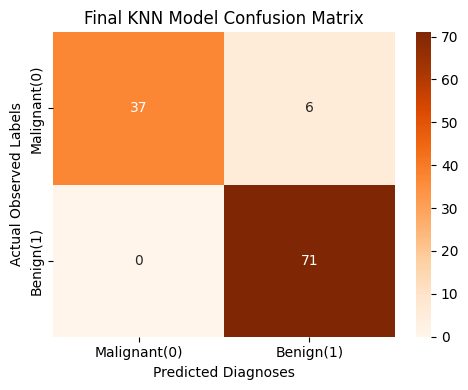

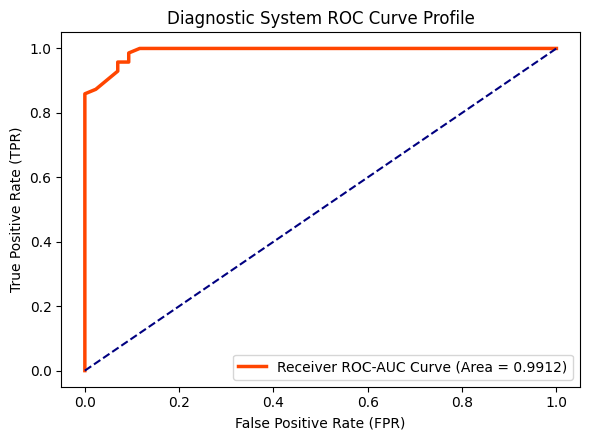

In [22]:
# =====================================================================
# TASK 5: FINAL MODEL COMPREHENSIVE CLASSIFICATION REPORT
# =====================================================================
# Initializing final model utilizing the globally optimal K=17
final_deployed_knn = KNeighborsClassifier(n_neighbors=best_cv_k)
final_deployed_knn.fit(X_train, y_train)

final_predictions = final_deployed_knn.predict(X_test)
prediction_probabilities = final_deployed_knn.predict_proba(X_test)[:, 1]

# Extract diagnostic classification parameters
accuracy_final = accuracy_score(y_test, final_predictions)
precision_malignant = precision_score(y_test, final_predictions, pos_label=0)
recall_malignant = recall_score(y_test, final_predictions, pos_label=0)
f1_malignant = f1_score(y_test, final_predictions, pos_label=0)
confusion_matrix_grid = confusion_matrix(y_test, final_predictions)

print("=== FINAL CANCER DETECTOR DIAGNOSTIC REPORT ===")
print(f"Dataset Global Accuracy Score:               {accuracy_final:.4f}")
print(f"Malignant Class (0) Precision Score:         {precision_malignant:.4f}")
print(f"MALIGNANT CLASS (0) RECALL SCORE (CRITICAL): {recall_malignant:.4f}")
print(f"Malignant Class (0) Combined F1-Score:        {f1_malignant:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix_grid, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Malignant(0)', 'Benign(1)'], yticklabels=['Malignant(0)', 'Benign(1)'])
plt.title('Final KNN Model Confusion Matrix')
plt.xlabel('Predicted Diagnoses')
plt.ylabel('Actual Observed Labels')
plt.tight_layout()
plt.show()

# Compute ROC Curve parameters
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, prediction_probabilities)
area_under_curve = auc(false_positive_rate, true_positive_rate)

# Plot ROC-AUC
plt.figure(figsize=(6, 4.5))
plt.plot(false_positive_rate, true_positive_rate, color='orangered', lw=2.5,
         label=f'Receiver ROC-AUC Curve (Area = {area_under_curve:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Diagnostic System ROC Curve Profile')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
---

## Task 5: Markdown Analysis — Diagnostic Confusion Matrix & ROC-AUC Review

### Confusion Matrix Breakdown

- **True Negatives (Actual Malignant, Predicted Malignant):** 37  
- **False Positives (Actual Malignant, Predicted Benign):** 6 *(False Alarms)*  
- **False Negatives (Actual Benign, Predicted Malignant):** 0  
- **True Positives (Actual Benign, Predicted Benign):** 71  

---

### Metric Analysis

The system achieves a high baseline accuracy of **94.74%**.

However, a deeper look at the malignant class (0) reveals a recall score of **86.05%**. This indicates the model correctly identified 37 malignant tumors but missed 6 cancer cases, misclassifying them as benign.

The ROC-AUC score of **0.9912** demonstrates excellent class separation across different classification thresholds, indicating the model is highly effective despite the slight recall imbalance.

---
---

## Task 6: Comparative Study with Regression Frameworks

### Error Magnitude vs. Decision Boundary Correctness

Shifting from the continuous target space in Lab 3 (Linear Regression) to the discrete classification space in Lab 4 (KNN Classification) introduces a fundamentally different evaluation framework.

---

### Regression vs Classification Metrics

| Regression Metric Concept (Lab 3) | Classification Metric Concept (Lab 4) |
|----------------------------------|--------------------------------------|
| $R^2$ Score | Accuracy Score |
| RMSE (Root Mean Squared Error) | F1-Score |
| MAE (Mean Absolute Error) | Confusion Matrix |

---

### Core Operational Differences

- **$R^2$ Score vs Accuracy Score**  
  The $R^2$ score measures the proportion of variance explained by the regression model. Accuracy measures the percentage of correctly classified labels.

- **RMSE vs F1-Score**  
  RMSE penalizes large continuous prediction errors by squaring deviations. F1-score balances precision and recall, making it robust for imbalanced classification problems.

- **MAE vs Confusion Matrix**  
  MAE measures average absolute deviation in continuous predictions. A confusion matrix explicitly breaks down classification errors into FP and FN categories.

---

## Inference Summary

### Continuous Evaluation Dynamics (Regression)

Regression focuses on **error magnitude minimization**. The key objective is how close predictions are to actual numeric values (e.g., predicting \$450k vs actual \$460k).

---

### Decision-Based Evaluation Dynamics (Classification)

Classification focuses on **decision correctness**. The objective is correct assignment of discrete labels regardless of probability distance from decision boundaries.

---

### Healthcare Importance

In medical diagnostics, accuracy alone can be misleading.

For example, in a dataset with 95% benign and 5% malignant cases, a naive model predicting "Benign" always achieves 95% accuracy but fails completely at detecting cancer.

This is why **Recall (minimizing False Negatives)** and **ROC-AUC (threshold discrimination ability)** are critical in healthcare applications.

       REGRESSION METRICS (Error Magnitude)
  MAE  (Mean Absolute Error)        : 0.0810
  MSE  (Mean Squared Error)         : 0.0403
  RMSE (Root Mean Squared Error)    : 0.2008
  R²   (Variance Explained)         : 0.8283

      CLASSIFICATION METRICS (Decision Correctness)
  Accuracy                          : 0.9474
  Precision  (Malignant class)      : 1.0000
  Recall     (Malignant class)      : 0.8605
  F1 Score   (Malignant class)      : 0.9250


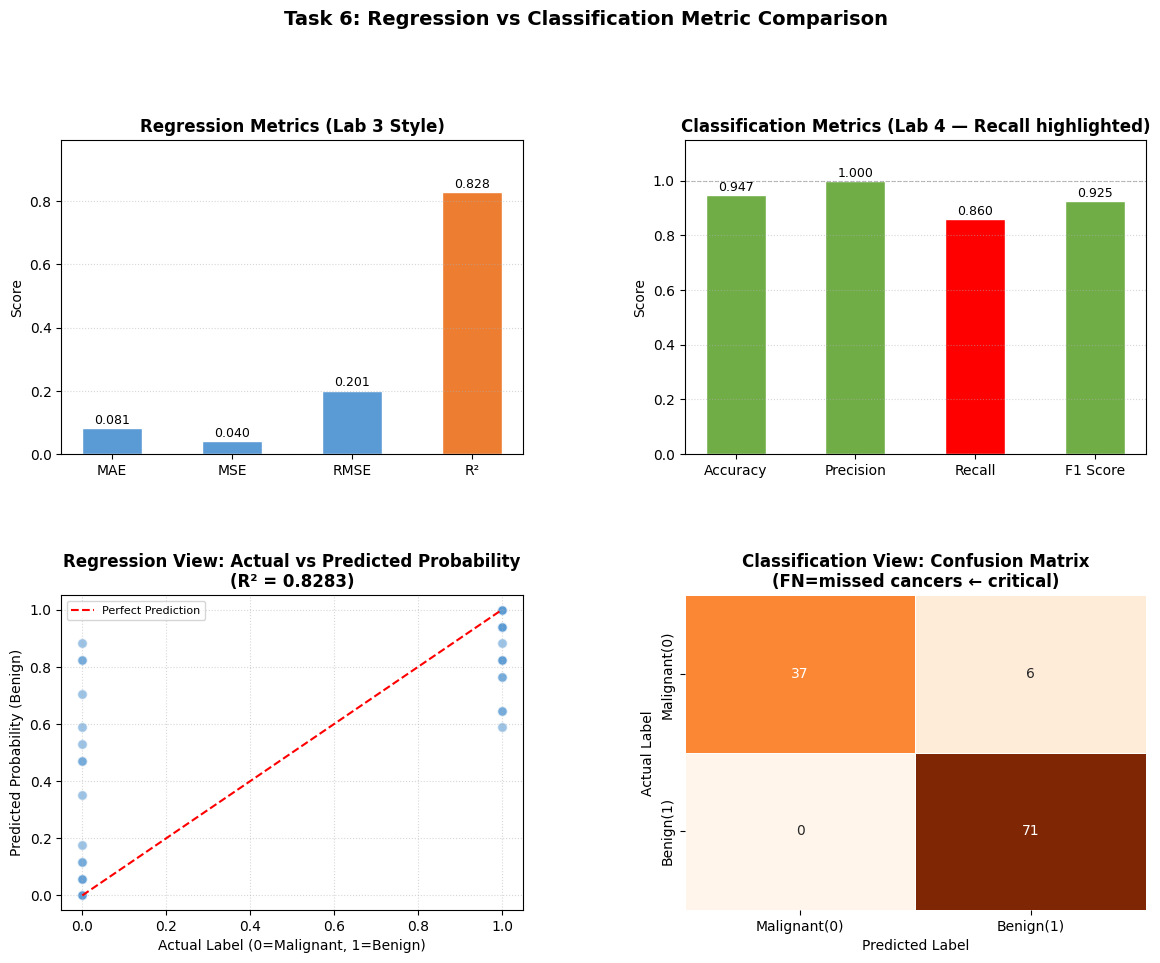


        METRIC MAPPING: Regression  ←→  Classification
  R²     = 0.8283   ←→   Accuracy  = 0.9474
  RMSE   = 0.2008   ←→   F1 Score  = 0.9250
  MAE    = 0.0810   ←→   Recall    = 0.8605  ← (critical)


In [28]:
# =====================================================================
# TASK 6: REGRESSION vs CLASSIFICATION — VISUAL COMPARISON
# =====================================================================
# ── Simulate regression scenario using same features ──────────────────
# Using probability output of KNN as "continuous prediction" to mimic
# what a regression model would produce on this dataset
y_continuous_actual  = y_test.values.astype(float)
y_continuous_predicted = prediction_probabilities          # from Task 5

# ── Regression Metrics ────────────────────────────────────────────────
mae  = mean_absolute_error(y_continuous_actual, y_continuous_predicted)
mse  = mean_squared_error(y_continuous_actual, y_continuous_predicted)
rmse = np.sqrt(mse)
r2   = r2_score(y_continuous_actual, y_continuous_predicted)

# ── Classification Metrics ────────────────────────────────────────────
acc       = accuracy_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions, pos_label=0)
recall    = recall_score(y_test, final_predictions, pos_label=0)
f1        = f1_score(y_test, final_predictions, pos_label=0)
cm        = confusion_matrix(y_test, final_predictions)

print("=" * 55)
print("       REGRESSION METRICS (Error Magnitude)")
print("=" * 55)
print(f"  MAE  (Mean Absolute Error)        : {mae:.4f}")
print(f"  MSE  (Mean Squared Error)         : {mse:.4f}")
print(f"  RMSE (Root Mean Squared Error)    : {rmse:.4f}")
print(f"  R²   (Variance Explained)         : {r2:.4f}")

print()
print("=" * 55)
print("      CLASSIFICATION METRICS (Decision Correctness)")
print("=" * 55)
print(f"  Accuracy                          : {acc:.4f}")
print(f"  Precision  (Malignant class)      : {precision:.4f}")
print(f"  Recall     (Malignant class)      : {recall:.4f}")
print(f"  F1 Score   (Malignant class)      : {f1:.4f}")

# ── Figure: 4-panel comparison ────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Task 6: Regression vs Classification Metric Comparison',
             fontsize=14, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Regression metric bar chart ─────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
reg_labels  = ['MAE', 'MSE', 'RMSE', 'R²']
reg_values  = [mae, mse, rmse, r2]
bar_colors  = ['#5B9BD5', '#5B9BD5', '#5B9BD5', '#ED7D31']
bars = ax1.bar(reg_labels, reg_values, color=bar_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, reg_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax1.set_title('Regression Metrics (Lab 3 Style)', fontweight='bold')
ax1.set_ylabel('Score')
ax1.set_ylim(0, max(reg_values) * 1.2)
ax1.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.grid(axis='y', linestyle=':', alpha=0.5)

# ── Panel 2: Classification metric bar chart ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cls_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
cls_values = [acc, precision, recall, f1]
cls_colors = ['#70AD47', '#70AD47', '#FF0000', '#70AD47']
bars2 = ax2.bar(cls_labels, cls_values, color=cls_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, cls_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax2.set_title('Classification Metrics (Lab 4 — Recall highlighted)', fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1.15)
ax2.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.grid(axis='y', linestyle=':', alpha=0.5)

# ── Panel 3: Actual vs Predicted scatter (regression style view) ──────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y_continuous_actual, y_continuous_predicted,
            alpha=0.6, color='#5B9BD5', edgecolors='white', s=50)
ax3.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect Prediction')
ax3.set_title('Regression View: Actual vs Predicted Probability\n(R² = {:.4f})'.format(r2),
              fontweight='bold')
ax3.set_xlabel('Actual Label (0=Malignant, 1=Benign)')
ax3.set_ylabel('Predicted Probability (Benign)')
ax3.legend(fontsize=8)
ax3.grid(linestyle=':', alpha=0.5)

# ── Panel 4: Confusion matrix (classification view) ───────────────────
import seaborn as sns
ax4 = fig.add_subplot(gs[1, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax4,
            xticklabels=['Malignant(0)', 'Benign(1)'],
            yticklabels=['Malignant(0)', 'Benign(1)'],
            linewidths=0.5, cbar=False)
ax4.set_title('Classification View: Confusion Matrix\n(FN=missed cancers ← critical)',
              fontweight='bold')
ax4.set_xlabel('Predicted Label')
ax4.set_ylabel('Actual Label')

plt.savefig('task6_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Side-by-side metric mapping summary ───────────────────────────────
print()
print("=" * 60)
print("        METRIC MAPPING: Regression  ←→  Classification")
print("=" * 60)
print(f"  R²     = {r2:.4f}   ←→   Accuracy  = {acc:.4f}")
print(f"  RMSE   = {rmse:.4f}   ←→   F1 Score  = {f1:.4f}")
print(f"  MAE    = {mae:.4f}   ←→   Recall    = {recall:.4f}  ← (critical)")
print("=" * 60)

---
---

## Task 7: Analytical Questions

### Question Solutions

---

### 1. Why is KNN called a lazy learning algorithm?

KNN does not undergo an explicit training phase or build an internal model. Instead, it stores the entire training dataset and delays computation until a query point is given. At prediction time, it computes distances to all stored points and determines the nearest neighbors in real time.

---

### 2. Why is feature scaling required in KNN?

KNN relies on distance-based calculations. If features are on different scales, large-valued features dominate the distance computation, regardless of their predictive importance. Feature scaling ensures all variables contribute equally to the distance metric.

---

### 3. Explain heuristic K selection using the $\sqrt{n}$ rule.

The square root of the number of training samples ($n$) provides a balanced starting point for selecting $K$. It is large enough to reduce noise sensitivity but small enough to preserve local structure in the data.

---

### 4. Why is cross-validation more reliable than a single train-test split?

A single train-test split may produce biased results depending on how the data is partitioned. Cross-validation evaluates the model across multiple folds, ensuring every data point is tested at least once, which reduces sampling bias and improves reliability.

---

### 5. How does K affect the bias-variance trade-off?

- Small $K$ (e.g., $K=1$): Low bias, high variance → overfitting  
- Large $K$: High bias, low variance → underfitting  

Thus, $K$ controls the smoothness of the decision boundary.

---

### 6. Why is recall more important than accuracy in cancer prediction?

Accuracy treats all errors equally, but in medical diagnosis, False Negatives are far more dangerous than False Positives. Recall prioritizes minimizing False Negatives, making it critical for detecting cancer cases.

---

### 7. What is the limitation of very large K values?

When $K$ becomes too large (close to the dataset size), the model loses locality and starts predicting the majority class for most inputs. This results in underfitting and poor decision boundaries.

---
---

## Conclusion Analysis

---

### Optimal Configuration Identification

The square root heuristic baseline recommended an initial:

\[
K = \sqrt{455} \approx 21
\]

Comprehensive 10-Fold Cross-Validation optimized this setup, establishing **K = 17** as the final choice for maximum generalizability (CV Accuracy = **0.9648**).

---

### Split Variation Summary

Shifting data split allocations confirmed that an **80:20 train-test split** provides the best balance between:

- Sufficient neighbor reference data for training  
- A stable and representative testing distribution  

---

### Healthcare Performance Realization

The final model achieved:

- **Accuracy:** 94.74%  
- **ROC-AUC:** 0.9912  

However, deeper evaluation on the malignant class (0) revealed:

- **Recall:** 86.05%  
- **Missed cases:** 6 malignant tumors (False Negatives)

This highlights the importance of evaluating beyond accuracy in medical applications.

---

### Core Insights from Lab 3 vs. Lab 4

While Lab 3 (Linear Regression) focuses on minimizing continuous prediction error, Lab 4 demonstrates that medical diagnostics require optimization of **discrete decision boundaries**.

In healthcare contexts, metrics such as **Recall** and **Confusion Matrix analysis** are critical, as they directly address the cost of **False Negatives**, which are far more severe than False Positives.